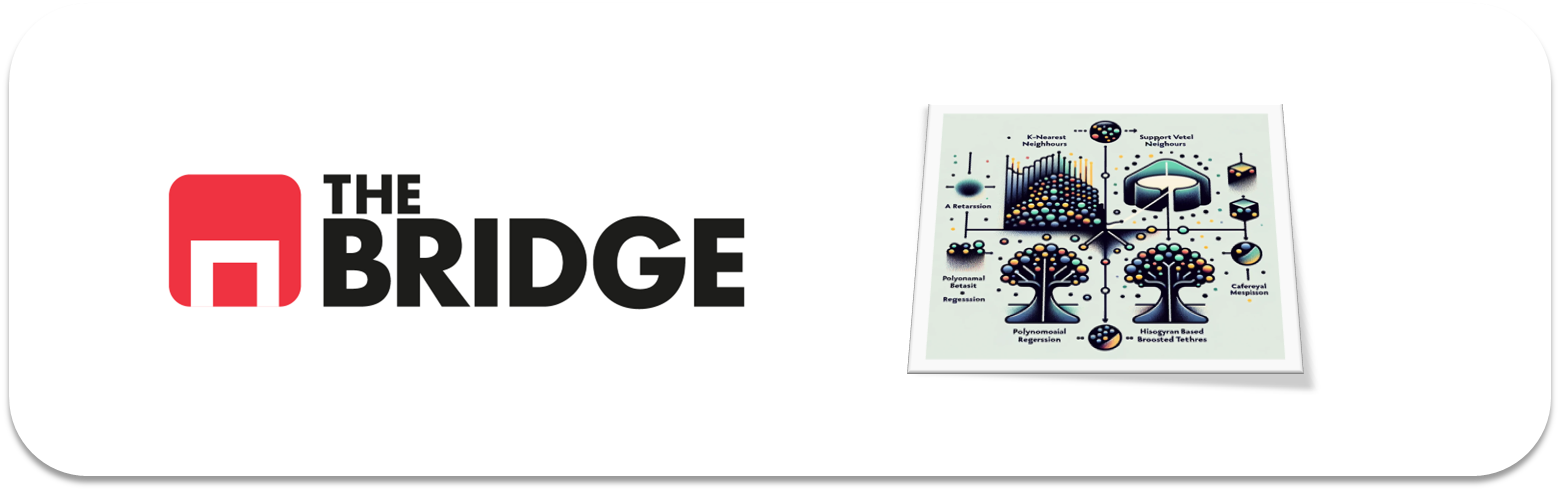

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en <ins>resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado</ins>. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
pd.options.mode.copy_on_write =True

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos <ins>la clasificación binaria con regresión logística</ins>, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita **predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años**. El dataset de partida lo puedes encontrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


In [3]:
from toolbox_ML import describe_df
describe_df(df)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
SeriousDlqin2yrs,numerica,0.0,2,0.02
RevolvingUtilizationOfUnsecuredLines,numerica,0.0,10764,85.86
age,numerica,0.0,78,0.62
NumberOfTime30-59DaysPastDueNotWorse,numerica,0.0,10,0.08
DebtRatio,numerica,0.0,11547,92.1
MonthlyIncome,numerica,5.8,4167,33.24
NumberOfOpenCreditLinesAndLoans,numerica,0.0,43,0.34
NumberOfTimes90DaysLate,numerica,0.0,13,0.1
NumberRealEstateLoansOrLines,numerica,0.0,16,0.13
NumberOfTime60-89DaysPastDueNotWorse,numerica,0.0,8,0.06


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [5]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

|Variable| descripción  | tipo  | nombre|
|---|---|---|---|
|'SeriousDlqin2yrs'| Cliente clasificado como moroso por haber excedido 90 días o más de impagos  | categórica binaria  | posible_moroso (TARGET)|
|'RevolvingUtilizationOfUnsecuredLines'|Ratio que relaciona el balance de la cuenta de crédito abierta con el límite de crédito establecido. Porcentaje del límite total de financiación disponible utilizado realmente.  |Numérica continua|uso_crédito|
|'age'|Edad del cliente|Numérica continua|edad|
|'NumberOfTime30-59DaysPastDueNotWorse'| Número de veces que el cliente se ha retrasado en el pago de 30 a 59 días, pero su posición no ha empeorado en los últimos dos años.|Numérica continua|retraso_30_a_59_dias|
|'DebtRatio'|Ratio que relaciona los gastos mensuales (amortización de la deuda y consumo diario) con los ingresos.   |Numérica continua|gastos_vs_ingresos|
|'MonthlyIncome'|Ingresos mensuales|Numérica continua|ingresos|
|'NumberOfOpenCreditLinesAndLoans'|Número de líneas de crédito y préstamos abiertos.|Númerica discreta|ptmos_otros|
|'NumberOfTimes90DaysLate'|Número de veces que el cliente se ha retrasado en el pago 90 días o más.|Numérica continua|retraso_mas_90_dias|
|'NumberRealEstateLoansOrLines'|Número de préstamos hipotecarios e inmobiliarios, incluidas líneas de crédito con garantía hipotecaria.|Númerica discreta|ptmos_hipotecario|
|'NumberOfTime60-89DaysPastDueNotWorse'| Número de veces que el cliente se ha retrasado en el pago de 60 a 89 días, pero su posición no ha empeorado en los últimos dos años.|Numérica continua|retraso_60_a_89_dias|
|'NumberOfDependents' | Número de miembros de la familia del cliente (excluyéndose ellos mismos).|Númerica discreta| personas_a_cargo  |


### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Un problema de clasificación, el target es 'SeriousDlqin2yrs' (posible_moroso). La predicción un cliente será moroso o no.

In [6]:
df_nombre= df.copy()
df_nombre.columns = ["posible_moroso", "uso_crédito", "edad", "retraso_30_a_59_dias", "gastos_vs_ingresos",
                     "ingresos", "ptmos_otros", "retraso_mas_90_dias", "ptmos_hipotecario",
                     "retraso_60_a_89_dias", "personas_a_cargo" ]

### #1.3
Pinta la distribución de frecuencias del target y coméntala

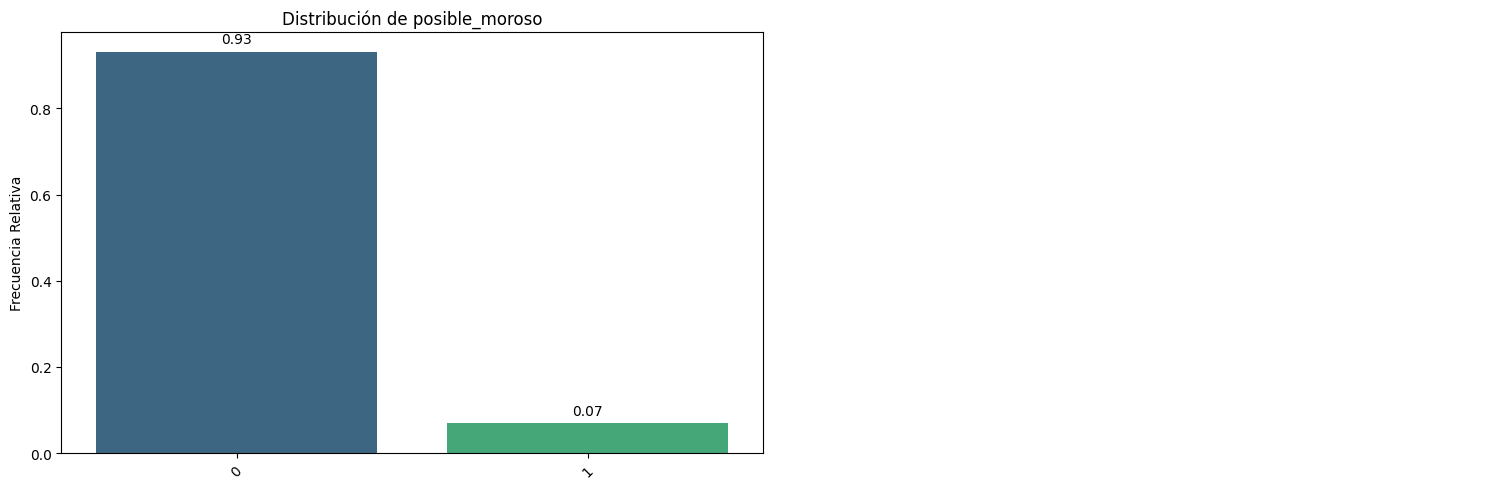

In [7]:
import bootcampviztools as bt
bt.pinta_distribucion_categoricas(df_nombre, ["posible_moroso"], relativa= True, mostrar_valores= True);

In [8]:
df_nombre.head(5)

,posible_moroso,uso_crédito,edad,retraso_30_a_59_dias,gastos_vs_ingresos,ingresos,ptmos_otros,retraso_mas_90_dias,ptmos_hipotecario,retraso_60_a_89_dias,personas_a_cargo
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


Es un target muy desequilibrado, está claro que las posibilidades de que alguién tenga dificultades financieras en los próximos dos años, según las muestras que manejamos es muy pequeña en comparación a que no lo sea. Aún así, teniendo en cuenta al negocio, daremos prioridad a que ningún posible moroso pase por no serlo, sacrificando posibles buenos clientes. (Esto lo he decidido yo ahora mismo, aunque no creo que me equivoque en absoluto).

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [10]:
train_set, test_set = train_test_split(df_nombre, test_size=0.2, stratify=df_nombre["posible_moroso"], random_state=42)
print(train_set.shape)
print(test_set.shape)

(10029, 11)
(2508, 11)


In [11]:
print(np.abs(df_nombre.corr()))

                      posible_moroso  uso_crédito      edad  \
posible_moroso              1.000000     0.281900  0.116908   
uso_crédito                 0.281900     1.000000  0.276080   
edad                        0.116908     0.276080  1.000000   
retraso_30_a_59_dias        0.115229     0.112593  0.058572   
gastos_vs_ingresos          0.017445     0.057167  0.103824   
ingresos                    0.022199     0.046920  0.053273   
ptmos_otros                 0.029063     0.162906  0.139891   
retraso_mas_90_dias         0.116649     0.106474  0.058873   
ptmos_hipotecario           0.005743     0.074352  0.028968   
retraso_60_a_89_dias        0.094080     0.089899  0.053216   
personas_a_cargo            0.045063     0.072876  0.221060   

                      retraso_30_a_59_dias  gastos_vs_ingresos  ingresos  \
posible_moroso                    0.115229            0.017445  0.022199   
uso_crédito                       0.112593            0.057167  0.046920   
edad           

<Axes: >

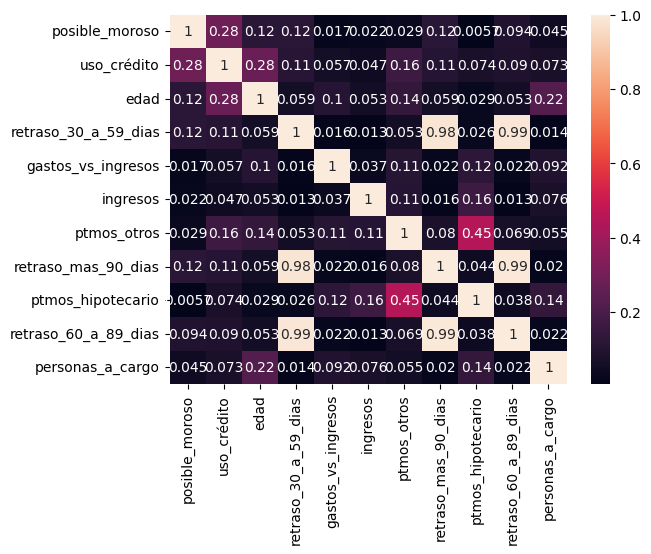

In [12]:
sns.heatmap(np.abs(df_nombre.corr()), annot=True,fmt=".2g")

In [13]:
X_train = train_set.drop("posible_moroso", axis=1)
y_train = train_set["posible_moroso"]
X_test = test_set.drop("posible_moroso", axis=1)
y_test= test_set["posible_moroso"]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(10029, 10)
(10029,)
(2508, 10)
(2508,)


In [18]:
print(X_train.describe())

        uso_crédito          edad  retraso_30_a_59_dias  gastos_vs_ingresos  \
count  10029.000000  10029.000000          10029.000000        10029.000000   
mean       0.330685     52.059228              0.384884            1.950129   
std        0.370456     15.085691              3.714056            9.284826   
min        0.000000     21.000000              0.000000            0.000000   
25%        0.030323     41.000000              0.000000            0.142167   
50%        0.163241     51.000000              0.000000            0.303945   
75%        0.584406     62.000000              0.000000            0.507164   
max        6.000000    101.000000             98.000000           99.000000   

            ingresos   ptmos_otros  retraso_mas_90_dias  ptmos_hipotecario  \
count    9446.000000  10029.000000         10029.000000       10029.000000   
mean     6828.929812      8.486389             0.229235           0.993120   
std     11109.771346      5.153172             3.68918

In [15]:
print(X_train.isna().sum())

uso_crédito               0
edad                      0
retraso_30_a_59_dias      0
gastos_vs_ingresos        0
ingresos                583
ptmos_otros               0
retraso_mas_90_dias       0
ptmos_hipotecario         0
retraso_60_a_89_dias      0
personas_a_cargo        141
dtype: int64


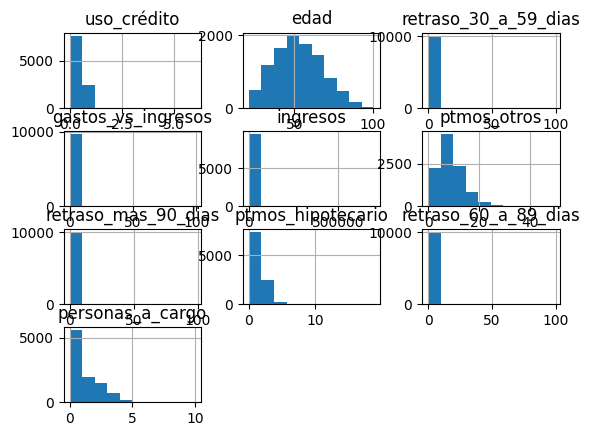

In [16]:
X_train.hist();

In [19]:
target = ["posible_moroso"]
features_num_cat =[ "edad", "retraso_30_a_59_dias", "gastos_vs_ingresos",
                     "ingresos", "retraso_mas_90_dias",
                     "retraso_60_a_89_dias"]
features_num_log= ["uso_crédito", "ptmos_otros", "ptmos_hipotecario", "personas_a_cargo"]


In [20]:
print(X_train[X_train.personas_a_cargo.isnull()])

       uso_crédito  edad  retraso_30_a_59_dias  gastos_vs_ingresos  ingresos  \
6865      0.005889    55                     0                75.0       NaN   
10077     0.123251    26                     0                 5.0       NaN   
4572      1.000000    61                     0                 0.0       NaN   
4984      0.000000    79                     0                 0.0       NaN   
3316      1.000000    22                     0                 0.0       NaN   
...            ...   ...                   ...                 ...       ...   
298       1.000000    22                     0                 3.0       NaN   
7066      0.021903    72                     0                46.0       NaN   
10241     0.011313    89                     0                14.0       NaN   
436       0.081546    60                     0                72.0       NaN   
3418      0.032299    70                     0                54.0       NaN   

       ptmos_otros  retraso_mas_90_dias

In [21]:
#Vamos a rellenar los nulos
X_train['ingresos'] = X_train['ingresos'].fillna(X_train['ingresos'].mean())
X_train['personas_a_cargo'] = X_train['personas_a_cargo'].fillna(X_train['personas_a_cargo'].mean())

print(X_train.isna().sum())

uso_crédito             0
edad                    0
retraso_30_a_59_dias    0
gastos_vs_ingresos      0
ingresos                0
ptmos_otros             0
retraso_mas_90_dias     0
ptmos_hipotecario       0
retraso_60_a_89_dias    0
personas_a_cargo        0
dtype: int64


In [22]:
X_test['ingresos'] = X_test['ingresos'].fillna(X_train['ingresos'].mean())
X_test['personas_a_cargo'] = X_test['personas_a_cargo'].fillna(X_train['personas_a_cargo'].mean())

print(X_test.isna().sum())

uso_crédito             0
edad                    0
retraso_30_a_59_dias    0
gastos_vs_ingresos      0
ingresos                0
ptmos_otros             0
retraso_mas_90_dias     0
ptmos_hipotecario       0
retraso_60_a_89_dias    0
personas_a_cargo        0
dtype: int64


In [23]:
# Tranformar a una forma gaussiana
X_train[features_num_log] = np.log1p(X_train[features_num_log])

In [24]:
X_test[features_num_log] = np.log1p(X_test[features_num_log])

In [27]:
#Juntamos las columnas a escalar (normalizar)
# features = pd.concat([X_train[features_num_cat], X_train[features_num_log]], axis=1) --> MAL

features= features_num_cat + features_num_log

Por defecto, pd.concat() concatena verticalmente (apila filas). Si quieres concatenar columnas horizontalmente, necesitas agregar axis=1.  
Esto sirve para unir DataFrames.

```python 
features = X_train[features_num_cat + features_num_log]
```
Esto funciona si features_num_cat y features_num_log son listas de nombres de columnas.

In [28]:
type(features)

list

In [29]:
# Normalizar columnas
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[features] = scaler.fit_transform(X_train[features])


In [30]:
X_train.describe()

,uso_crédito,edad,retraso_30_a_59_dias,gastos_vs_ingresos,ingresos,ptmos_otros,retraso_mas_90_dias,ptmos_hipotecario,retraso_60_a_89_dias,personas_a_cargo
count,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04,1.002900e+04
mean,1.154836e-16,-5.685617e-17,1.452401e-17,3.117348e-17,1.751737e-16,-1.445316e-16,-2.125464e-18,6.518091e-17,-3.542441e-19,-2.833952e-17
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-9.997589e-01,-2.058956e+00,-1.036342e-01,-2.100445e-01,-6.333961e-01,-3.427721e+00,-6.214018e-02,-1.101964e+00,-5.488286e-02,-8.254698e-01
25%,-8.812348e-01,-7.331305e-01,-1.036342e-01,-1.947319e-01,-3.052399e-01,-4.870781e-01,-6.214018e-02,-1.101964e+00,-5.488286e-02,-8.254698e-01
50%,-3.998107e-01,-7.021760e-02,-1.036342e-01,-1.773072e-01,-1.057306e-01,1.783729e-01,-6.214018e-02,2.688619e-01,-5.488286e-02,-8.254698e-01
75%,8.261956e-01,6.589866e-01,-1.036342e-01,-1.554188e-01,1.086190e-01,6.505178e-01,-6.214018e-02,1.070744e+00,-5.488286e-02,4.733860e-01
max,6.720946e+00,3.244347e+00,2.628393e+01,1.045305e+01,6.452480e+01,2.992707e+00,2.650331e+01,4.822648e+00,2.663546e+01,3.667833e+00


In [31]:
X_test[features] = scaler.transform(X_test[features])

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [34]:
from sklearn.metrics import get_scorer_names
print(sorted(get_scorer_names()))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [32]:
# Elección de modelos:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
rfc= RandomForestClassifier(random_state=42)
gbc = GradientBoostingClassifier(random_state=42)
knn_cl = KNeighborsClassifier()

In [39]:
model_names = ["RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier"]
model_set = [rfc, gbc, knn_cl]
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(type(modelo).__name__)
    metricas_cv[nombre] = cross_val_score(modelo, X_train, y_train, cv = 3, scoring = "balanced_accuracy")
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmax(valores)]

RandomForestClassifier
GradientBoostingClassifier
KNeighborsClassifier


In [41]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, balanced_accuracy: {valores}")
print(f"El ganador es {ganador}")

Model <RandomForestClassifier>, balanced_accuracy: [0.59252573 0.57046537 0.59907605]
Model <GradientBoostingClassifier>, balanced_accuracy: [0.59840501 0.59059833 0.59698736]
Model <KNeighborsClassifier>, balanced_accuracy: [0.5412408  0.55886744 0.53743017]
El ganador es GradientBoostingClassifier


In [48]:
from sklearn.model_selection import GridSearchCV

params_grid = {
     "n_estimators": [50, 100, 150],
     "learning_rate": [0.1, 0.4],
     "max_depth": [3, 5, 8],
     "max_features": [None, 'sqrt', 'log2'],
     "min_samples_split": [ 2, 10, 55, 100],
}


grid_gbc = GridSearchCV(
    gbc,
    param_grid = params_grid,
    cv=5,
    scoring='balanced_accuracy',         
    n_jobs=-1
)

grid_gbc.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.4], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_split': [2, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [49]:
print(grid_gbc.best_estimator_)
print(grid_gbc.best_params_)
print(grid_gbc.best_score_)

GradientBoostingClassifier(learning_rate=0.4, max_depth=5,
                           min_samples_split=100, n_estimators=150,
                           random_state=42)
{'learning_rate': 0.4, 'max_depth': 5, 'max_features': None, 'min_samples_split': 100, 'n_estimators': 150}
0.6173212191579689


In [50]:
y_pred = grid_gbc.best_estimator_.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2335
           1       0.40      0.27      0.32       173

    accuracy                           0.92      2508
   macro avg       0.67      0.62      0.64      2508
weighted avg       0.91      0.92      0.91      2508



In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
grid_gbc.fit(X_train_balanced, y_train_balanced)

y_pred_balanced = grid_gbc.best_estimator_.predict(X_test)
print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2335
           1       0.39      0.26      0.31       173

    accuracy                           0.92      2508
   macro avg       0.67      0.61      0.63      2508
weighted avg       0.91      0.92      0.91      2508



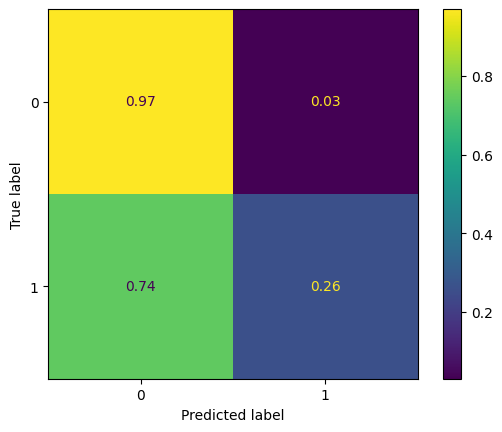

In [53]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced, normalize= "true")

In [54]:
rfc.fit(X_train_balanced, y_train_balanced)
y_pred_rfc = rfc.predict(X_test)
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2335
           1       0.43      0.32      0.37       173

    accuracy                           0.92      2508
   macro avg       0.69      0.64      0.66      2508
weighted avg       0.91      0.92      0.92      2508



In [57]:
params_grid = {
     "n_estimators": [50, 100, 150],
     "max_depth": [3, 5, 8],
     "max_features": [None, 'sqrt', 'log2'],
     "min_samples_split": [ 2, 10, 55, 100],
}
rfc = RandomForestClassifier(random_state=42,class_weight= "balanced")

grid_rfc = GridSearchCV(
    rfc,
    param_grid = params_grid,
    cv=5,
    scoring='balanced_accuracy',         
    n_jobs=-1)

grid_rfc.fit(X_train_balanced, y_train_balanced)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_split': [2, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [59]:
y_pred_best = grid_rfc.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2335
           1       0.35      0.45      0.39       173

    accuracy                           0.90      2508
   macro avg       0.65      0.69      0.67      2508
weighted avg       0.92      0.90      0.91      2508



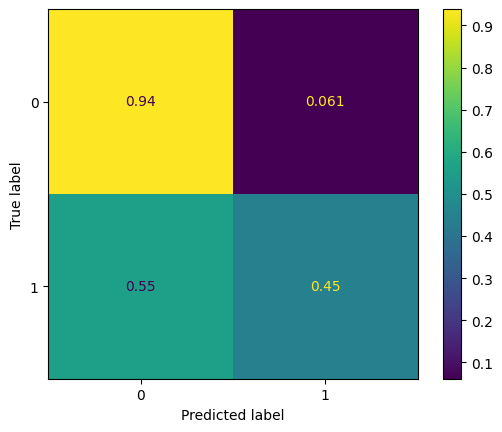

In [60]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, normalize= "true")

In [61]:
params_grid = {
     "n_estimators": [50, 100, 150],
     "max_depth": [3, 5, 8],
     "max_features": [None, 'sqrt', 'log2'],
     "min_samples_split": [ 2, 10, 55, 100],
}
rfc = RandomForestClassifier(random_state=42,class_weight= "balanced")

grid_rfc = GridSearchCV(
    rfc,
    param_grid = params_grid,
    cv=5,
    scoring='recall',         
    n_jobs=-1)

grid_rfc.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_split': [2, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [62]:
y_pred_best = grid_rfc.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85      2335
           1       0.18      0.75      0.29       173

    accuracy                           0.75      2508
   macro avg       0.58      0.75      0.57      2508
weighted avg       0.92      0.75      0.81      2508



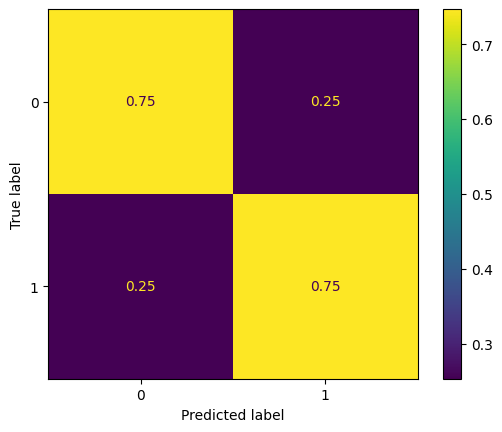

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, normalize= "true")